#### For some actions, you may want to require human approval before running to ensure that everything is running as intended.

In [31]:
import operator,json
from typing import Annotated
from typing import TypedDict, Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver

from langgraph.graph import StateGraph,END,START
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

In [2]:
# from langchain_google_genai import ChatGoogleGenerativeAI
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    # Point to the OpenAI-compatible "door"
    base_url="http://localhost:11434/v1", 
    
    # Required but ignored by Ollama
    api_key="ollama", 
    
    # The exact name you see in 'ollama list'
    model="qwen2.5:1.5b", 
    
    temperature=0
)

# Test it
# print(llm.invoke("What is the time complexity of Merge Sort?").content)

In [23]:
print(llm.invoke("What is the time complexity of Merge Sort?").content)

The time complexity of Merge Sort is O(n log n). This means that as the size of the input list increases, the time it takes to sort the list grows logarithmically with respect to its size.

Here's a brief explanation:

1. **Merge Sort Algorithm**:
   - The algorithm divides the array into two halves until each subarray contains only one element.
   - Then, it merges these sorted subarrays back together in a sorted manner.

2. **Time Complexity Analysis**:
   - Each merge operation takes O(n) time because merging involves comparing and combining elements from both subarrays.
   - The number of merge operations is proportional to the height of the recursion tree, which is log n (since each level reduces the problem size by half).
   - Therefore, the overall time complexity is O(n * log n).

3. **Space Complexity**:
   - Merge Sort requires additional space for merging subarrays.
   - The space complexity is O(n) due to the temporary storage needed during the merge process.

In summary, w

In [33]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [ ]:
# llm.invoke("hi")

AIMessage(content='Hello! 👋  How can I help you today?\n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 10, 'total_tokens': 24, 'completion_time': 0.025454545, 'prompt_time': 3.9e-07, 'queue_time': 0.020031796, 'total_time': 0.025454935}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run-e177460b-748e-4c60-9f9c-e1d0e138a7cf-0', usage_metadata={'input_tokens': 10, 'output_tokens': 14, 'total_tokens': 24})

In [ ]:
# llm.invoke("hi").content

'Hello! 👋  How can I help you today?\n'

In [34]:
@tool
def multiply(first_number:int, second_number:int)->int:
    """multiply two integer number"""
    return first_number * second_number

In [10]:
multiply({"first_number":24,"second_number":364})

TypeError: 'StructuredTool' object is not callable

In [5]:
multiply.invoke({"first_number":24,"second_number":364})

8736

In [35]:
@tool
def search(query:str):
    """perform the web search on the user query. Use it when you don't know the answer to the question and need to search the web for the answer"""
    tavily=TavilySearchResults()
    result=tavily.invoke(query)
    return result

In [16]:
search.invoke("who is a current president of USA?")

C:\Users\Manas tiwari\AppData\Local\Temp\ipykernel_30704\1922640126.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


[{'title': 'Presidents, vice presidents, and first ladies | USAGov',
  'url': 'https://www.usa.gov/presidents',
  'content': "### Current president\n\nThe 47th and current president of the United States is Donald John Trump. He was sworn into office on January 20, 2025.\n\n### Former U.S. presidents\n\nThe United States has had 45 former U.S. presidents. Read about past presidents and vice presidents.\n\nMany former presidents have presidential libraries and museums you can visit to learn about their lives and their time in office. Find presidential libraries and museums.\n\n### Requirements to be eligible to become president\n\nAccording to Article II of the U.S. Constitution, the president must:\n\nLearn about the U.S. presidential election process.\n\n## Vice president of the United States [...] ### Current first lady\n\nThe current first lady of the United States is Melania Trump.\n\n### Former first ladies\n\nFind a list of former first ladies and their presidential spouses.\n\nSe

In [36]:
tools=[search,multiply]

In [37]:
model_with_tools = llm.bind_tools(tools)

In [9]:
tool_mapping={tool.name: tool for tool in tools}

In [10]:
tool_mapping

{'search': StructuredTool(name='search', description='perform the web search on the user query', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000019F1D36E2A0>),
 'multiply': StructuredTool(name='multiply', description='multiply two integer number', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000019F1D303A60>)}

In [ ]:
# response = model_with_tools.invoke("who is a current president of USA?")

In [ ]:
# response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_j29h', 'function': {'arguments': '{"query":"Who is the current president of the USA?"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 1076, 'total_tokens': 1162, 'completion_time': 0.156363636, 'prompt_time': 0.034321225, 'queue_time': 0.003081050000000002, 'total_time': 0.190684861}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d42ca288-7f30-452a-808d-2b11b24f7477-0', tool_calls=[{'name': 'search', 'args': {'query': 'Who is the current president of the USA?'}, 'id': 'call_j29h', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1076, 'output_tokens': 86, 'total_tokens': 1162})

In [ ]:
# tool_details=response.additional_kwargs.get("tool_calls")

In [ ]:
# tool_details

[{'id': 'call_j29h',
  'function': {'arguments': '{"query":"Who is the current president of the USA?"}',
   'name': 'search'},
  'type': 'function'}]

In [ ]:
# tool_details[0]["function"]["name"]

'search'

In [ ]:
# tool_details[0]["function"]["arguments"]

'{"query":"Who is the current president of the USA?"}'

In [ ]:
# json.loads(tool_details[0]["function"]["arguments"])

{'query': 'Who is the current president of the USA?'}

In [126]:
tool_mapping[tool_details[0]["function"]["name"]].invoke(json.loads(tool_details[0]["function"]["arguments"]))

[{'url': 'https://en.wikipedia.org/wiki/Presidency_of_Joe_Biden',
  'content': 'On November 23, after Michigan certified its results, Murphy issued the letter of ascertainment, granting the Biden transition team access to federal funds and resources for an orderly transition.[29]\nTwo days after becoming the projected winner of the 2020 election, Biden announced the formation of a task force to advise him on the COVID-19 pandemic during the transition, co-chaired by former Surgeon General Vivek Murthy, former FDA commissioner David A. Kessler, and Yale University\'s Marcella Nunez-Smith.[30]\nOn January 5, 2021, the Democratic Party won control of the United States Senate, effective January 20, as a result of electoral victories in Georgia by Jon Ossoff in a runoff election for a six-year term and Raphael Warnock in a special runoff election for a two-year term.[31][32] President-elect Biden had supported and campaigned for both candidates prior to the runoff elections on January 5.[33

In [22]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]  # This is the state of the agent, which is a sequence of messages. The operator.add annotation indicates that when we add two AgentState objects together, we want to concatenate their messages.

In [34]:
cc = model_with_tools.invoke("who is a current president of USA?")

In [35]:
cc

AIMessage(content='', additional_kwargs={'function_call': {'name': 'search', 'arguments': '{"query": "current president of USA"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d382a-951d-7783-a990-c0443f8dd316-0', tool_calls=[{'name': 'search', 'args': {'query': 'current president of USA'}, 'id': '6b11b3e7-2821-4410-b89b-1038d435fa25', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 100, 'output_tokens': 16, 'total_tokens': 116, 'input_token_details': {'cache_read': 0}})

In [65]:
cc.tool_calls[0]

{'name': 'search',
 'args': {'query': 'current president of USA'},
 'id': '6b11b3e7-2821-4410-b89b-1038d435fa25',
 'type': 'tool_call'}

In [38]:
def invoke_model(state:AgentState):
    messages = state['messages']
    question = messages[-1]   ## Fetching the user question
    return {"messages":[model_with_tools.invoke(question)]}

### Custom way to add Human in the loop

In [39]:
def invoke_tool(state: AgentState):
    # Access tool_calls directly from the AIMessage object
    tool_calls = state['messages'][-1].tool_calls
    
    if not tool_calls:
        raise Exception("no tool call found")
    
    tool_details = tool_calls[0]
    print(f'Selected tool: {tool_details["name"]}')
    
    if tool_details["name"] == "search":
        response = input(prompt=f"[y/n] continue with expensive web search?")
        if response == "n":
            raise Exception("web search discard")
    
    # Extract args - pass the entire dict to the tool's invoke method
    args = tool_details.get("args", {})
    if isinstance(args, str):
        args = json.loads(args) if args else {}
    
    response = tool_mapping[tool_details['name']].invoke(args)
    return {"messages": [response]}

In [40]:
def router(state):
    # Access tool_calls directly from the AIMessage object
    tool_calls = state['messages'][-1].tool_calls
    if tool_calls:
        return "tool"
    else:
        return "end"

In [41]:
graph = StateGraph(AgentState) ### StateGraph with AgentState

graph.add_node("ai_assistant", invoke_model)

graph.add_node("tool", invoke_tool)

In [42]:
graph.add_conditional_edges("ai_assistant", router, {"tool": "tool","end": END,})

graph.add_edge("tool", END)

#graph.add_edge("tool", "ai_assistant")

graph.set_entry_point("ai_assistant")

In [43]:
app = graph.compile()

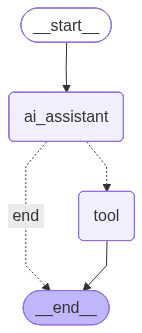

In [29]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
for s in app.stream({"messages": ["who is upcoming president of USA?"]}):
    print(list(s.values())[0])
    print("----")

In [31]:
for s in app.stream({"messages": ["what is multiplication of 23 and 46?"]}):
    print(list(s.values())[0])
    print("----")

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 203, 'total_tokens': 232, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2.5:1.5b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-415', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d3841-8aa8-7461-8a34-8bbf55eeffe1-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': 23, 'second_number': 46}, 'id': 'call_kdf1hmcu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 203, 'output_tokens': 29, 'total_tokens': 232, 'input_token_details': {}, 'output_token_details': {}})]}
----
Selected tool: multiply
{'messages': [1058]}
----


In [33]:
for s in app.stream({"messages": ["what is the total amount of money exist over the earth?"]}):
    print(list(s.values())[0])
    print("----")

{'messages': [AIMessage(content='I can help you search for information on this topic. Please provide me with a query or question related to your request, and I will try my best to find relevant data for you.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 203, 'total_tokens': 241, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2.5:1.5b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-197', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d3842-07d3-7e83-82da-310ec56ed900-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 203, 'output_tokens': 38, 'total_tokens': 241, 'input_token_details': {}, 'output_token_details': {}})]}
----


#### LangGraph supports human-in-the-loop workflows in a number of ways. In this section, we will use LangGraph's interrupt_before functionality to always break the tool node.

In [48]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name="openai/gpt-oss-120b")

In [49]:
print(llm.invoke("What is the time complexity of Merge Sort?").content)

**Merge Sort** is a classic divide‑and‑conquer sorting algorithm. Its time complexity can be analyzed by looking at how the algorithm splits the input and then merges the pieces back together.

---

## 1. Recurrence relation

For an input of size **n**:

1. **Divide:** Split the array into two halves of size ≈ n/2.  
2. **Conquer:** Recursively sort each half.  
3. **Combine:** Merge the two sorted halves in linear time **O(n)**.

This yields the recurrence:

\[
T(n) = 2 \, T\!\left(\frac{n}{2}\right) + O(n)
\]

---

## 2. Solving the recurrence

Using the Master Theorem (case 2, where \(a = 2\), \(b = 2\), \(f(n) = \Theta(n)\)):

\[
T(n) = \Theta\bigl(n \log_2 n\bigr)
\]

Thus the dominant term is **\(n \log n\)**.

---

## 3. Complexity summary

| Scenario | Time Complexity | Reason |
|----------|----------------|--------|
| **Best case** | \( \Theta(n \log n) \) | Even if the input is already sorted, the algorithm still performs the same number of splits and merges. (Some optimized 

In [50]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [51]:
tavily=TavilySearchResults()

C:\Users\Manas tiwari\AppData\Local\Temp\ipykernel_18556\1844490623.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [52]:
tools = [tavily]

In [53]:
llm_with_tools = llm.bind_tools(tools)

In [64]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000217FEE76850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000217FEE760D0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [65]:
def ai_assistant(state: AgentState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [55]:
memory = MemorySaver()

In [66]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node("ai_assistant", ai_assistant)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [67]:
graph_builder.add_edge(START, "ai_assistant")

graph_builder.add_conditional_edges(
    "ai_assistant",
    tools_condition,
)
graph_builder.add_edge("tools", "ai_assistant")

In [68]:
app2 = graph_builder.compile(
    checkpointer=memory,
    # This is new!
    interrupt_before=["tools"],
    # Note: can also interrupt __after__ tools, if desired.
    # interrupt_after=["tools"]
)

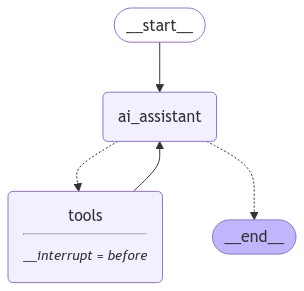

In [149]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [59]:
user_input = "what is current a capital of india?"
config = {"configurable": {"thread_id": "1"}}

In [60]:
# The config is the **second positional argument** to stream() or invoke()!
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [61]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

what is current a capital of india?
================================== Ai Message ==================================

The current capital of India is **New Delhi**.


In [62]:
snapshot = app2.get_state(config)

In [63]:
snapshot.next

()

In [155]:
last_message=snapshot.values["messages"][-1]

In [156]:
last_message.tool_calls

[{'name': 'search',
  'args': {'query': 'what is the capital of india'},
  'id': 'call_5pgj',
  'type': 'tool_call'}]

In [159]:
# `None` will append nothing new to the current state, letting it resume as if it had never been interrupted
events = app2.stream(None, config, stream_mode="values")

In [160]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  search (call_6kp1)
 Call ID: call_6kp1
  Args:
    query: what is the capital of india
================================= Tool Message =================================
Name: search

[{"url": "https://www.yahoo.com/news/capital-india-territory-came-plus-130045224.html", "content": "About 1.4 billion people live in India, and the country is predicted to top China as the world’s most populous country by mid-2023, the United Nations reports. The capital of India is New Delhi, located in the north-central part of the country to the west of the Yamuna River. Mumbai, the state capital of Maharashtra, is often considered the financial capital of India because of its role in the national and international economy. New Delhi is part of one of India’s union territories, the National Capital Territory of Dehli. This article originally appeared on USA TODAY: What is the capital of India?"}, {"url": "https

In [69]:
user_input = "what is a weather there?"

config = {"configurable": {"thread_id": "1"}}

In [70]:
# The config is the **second positional argument** to stream() or invoke()!
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [71]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather there?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_743029fb-ed3e-49f2-986a-2878237fc645)
 Call ID: fc_743029fb-ed3e-49f2-986a-2878237fc645
  Args:
    query: current weather New Delhi


In [72]:
snapshot = app2.get_state(config)

In [73]:
snapshot.next

('tools',)

In [74]:
last_message=snapshot.values["messages"][-1]

In [75]:
last_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'current weather New Delhi'},
  'id': 'fc_743029fb-ed3e-49f2-986a-2878237fc645',
  'type': 'tool_call'}]

In [76]:
# `None` will append nothing new to the current state, letting it resume as if it had never been interrupted
events = app2.stream(None, config, stream_mode="values")

In [77]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_743029fb-ed3e-49f2-986a-2878237fc645)
 Call ID: fc_743029fb-ed3e-49f2-986a-2878237fc645
  Args:
    query: current weather New Delhi
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Weather Forecast for Delhi for Sunday 29 March", "url": "https://www.metcheck.com/WEATHER/dayforecast.asp?location=Delhi&locationID=2015798&lat=42.429710&lon=-91.330980&dateFor=29/03/2026", "content": "|  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |\n ---  ---  ---  ---  ---  ---  ---  ---  ---  ---  --- |\n| 2:00 | 3:00 | 4:00 | 5:00 | 6:00 | 7:00 | 8:00 | 9:00 | 10:00 | 11:00 | 12:00 | 13:00 | 14:00 | 15:00 | 16:00 | 17:00 | 18:00 | 19:00 | 20:00 | 21:00 | 22:00 | 23:00 |\n|  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |\n\n\")\n\n\")\n\n\")\n\n\")\n\n\")\n\n\")\n\n\

In [78]:
app2.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='what is current a capital of india?', additional_kwargs={}, response_metadata={}, id='c4593b8b-5094-4607-9a98-7a5985c36720'), AIMessage(content='The current capital of India is **New\u202fDelhi**.', additional_kwargs={'reasoning_content': 'The user asks: "what is current a capital of india?" Likely they want the capital of India. The current capital is New Delhi. Provide answer. No need for search as it\'s well known.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 162, 'total_tokens': 225, 'completion_time': 0.137512582, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.007359881, 'prompt_tokens_details': None, 'queue_time': 0.049146548, 'total_time': 0.144872463}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d384f-9dd8-7862-9b1c-a73

In [79]:
snapshot=app2.get_state(config)

In [80]:
snapshot.next

()

In [173]:
user_input = "give me the recent news of it?"

config = {"configurable": {"thread_id": "1"}}

In [174]:
# The config is the **second positional argument** to stream() or invoke()!
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [175]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

give me the recent news of it?
================================== Ai Message ==================================
Tool Calls:
  search (call_k054)
 Call ID: call_k054
  Args:
    query: recent news new delhi


In [176]:
snapshot=app2.get_state(config)

In [177]:
current_message = snapshot.values["messages"][-1]

In [178]:
current_message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  search (call_k054)
 Call ID: call_k054
  Args:
    query: recent news new delhi


In [179]:
tool_call_id = current_message.tool_calls[0]["id"] 

In [180]:
tool_call_id

'call_k054'

In [181]:
from langchain_core.messages import AIMessage, ToolMessage

In [ ]:
answer = "it is just related to raining which is happing on daily basis"

In [182]:
new_messages = [
    ToolMessage(content=answer, tool_call_id=tool_call_id),
    AIMessage(content=answer),
]

In [183]:
app2.update_state(
    config,
    {"messages": new_messages},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efa3f9e-a414-6c0a-800e-b3cf9a8c9199'}}

In [184]:
print(app2.get_state(config).values["messages"][-1:])

[AIMessage(content='it is just related to raining which is happing on daily basis', additional_kwargs={}, response_metadata={}, id='86ee0c6d-7771-4ed6-8bd2-242adace39be')]


In [83]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    api_key=os.environ["HUGGINGFACE_API_KEY"],
)

completion = client.chat.completions.create(
    model="openai/gpt-oss-120b:fastest",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ],
)

print(completion.choices[0].message.content)

The capital of France is **Paris**.
